In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/youtube.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56589 entries, 0 to 56588
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   56589 non-null  int64  
 1   video_id                56589 non-null  object 
 2   trending_date           56589 non-null  object 
 3   title                   56589 non-null  object 
 4   channel_title           56588 non-null  object 
 5   category_id             56588 non-null  float64
 6   publish_date            56588 non-null  object 
 7   time_frame              56588 non-null  object 
 8   published_day_of_week   56588 non-null  object 
 9   publish_country         56588 non-null  object 
 10  tags                    56588 non-null  object 
 11  views                   56588 non-null  float64
 12  likes                   56588 non-null  float64
 13  dislikes                56588 non-null  float64
 14  comment_count           56588 non-null

In [7]:
df.describe()

,index,category_id,views,likes,dislikes,comment_count
count,56589.000000,56588.000000,5.658800e+04,5.658800e+04,5.658800e+04,5.658800e+04
mean,28294.000000,19.522602,2.306291e+06,7.342396e+04,4.556540e+03,8.749345e+03
std,16335.981529,7.553697,7.627222e+06,2.294559e+05,4.596427e+04,4.370283e+04
min,0.000000,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,14147.000000,10.000000,1.860515e+05,4.250000e+03,1.580000e+02,4.970000e+02
50%,28294.000000,23.000000,5.850240e+05,1.547600e+04,5.460000e+02,1.635000e+03
75%,42441.000000,24.000000,1.686267e+06,5.200000e+04,1.801000e+03,5.384250e+03
max,56588.000000,43.000000,2.252119e+08,5.613827e+06,1.944971e+06,1.626501e+06


In [8]:
df.isnull().sum()

,0
index,0
video_id,0
trending_date,0
title,0
channel_title,1
category_id,1
publish_date,1
time_frame,1
published_day_of_week,1
publish_country,1


In [9]:
df = df.dropna()
# NEW - keep peak views as the label target first
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')

df_peak = df.groupby('video_id')['views'].max().rename('peak_views').reset_index()

# Now keep the EARLIEST trending snapshot per video (early signals)
df = df.sort_values('trending_date', ascending=True).drop_duplicates(subset='video_id').copy()

# Attach peak views to that earliest row
df = df.merge(df_peak, on='video_id')
df['publish_date'] = pd.to_datetime(df['publish_date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['publish_date'])

In [10]:
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))
df['title_char_length'] = df['title'].apply(lambda x: len(str(x)))
df['tags_count'] = df['tags'].apply(lambda x: len(str(x).split('|')) if str(x) != '[none]' else 0)

df['like_ratio']     = df['likes'] / (df['likes'] + df['dislikes'] + 1)
df['comment_ratio']  = df['comment_count'] / (df['likes'] + 1)
df['dislike_ratio']  = df['dislikes'] / (df['likes'] + df['dislikes'] + 1)
df['hour'] = df['time_frame'].str.extract(r'(\d+):').astype(float)

In [11]:
from sklearn.preprocessing import LabelEncoder
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_num'] = df['published_day_of_week'].apply(
    lambda x: day_order.index(x) if x in day_order else -1
)
le_country = LabelEncoder()
df['country_enc'] = le_country.fit_transform(df['publish_country'])
df['comments_disabled_int'] = df['comments_disabled'].astype(int)
df['ratings_disabled_int']  = df['ratings_disabled'].astype(int)

In [12]:
# NEW - labels based on peak views (future outcome)
VIEWS_MEDIAN_EDA = df['peak_views'].median()
df['viral_eda'] = (df['peak_views'] > VIEWS_MEDIAN_EDA).astype(int)


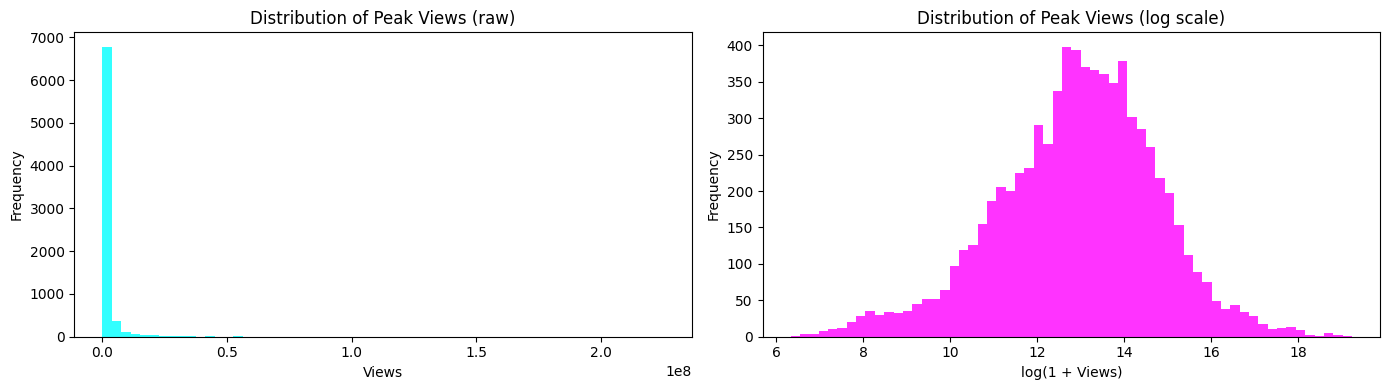

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plt.style.use('dark_background')

axes[0].hist(df['peak_views'], bins=60, color='cyan', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution of Peak Views (raw)')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['peak_views']), bins=60, color='magenta', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution of Peak Views (log scale)')
axes[1].set_xlabel('log(1 + Views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

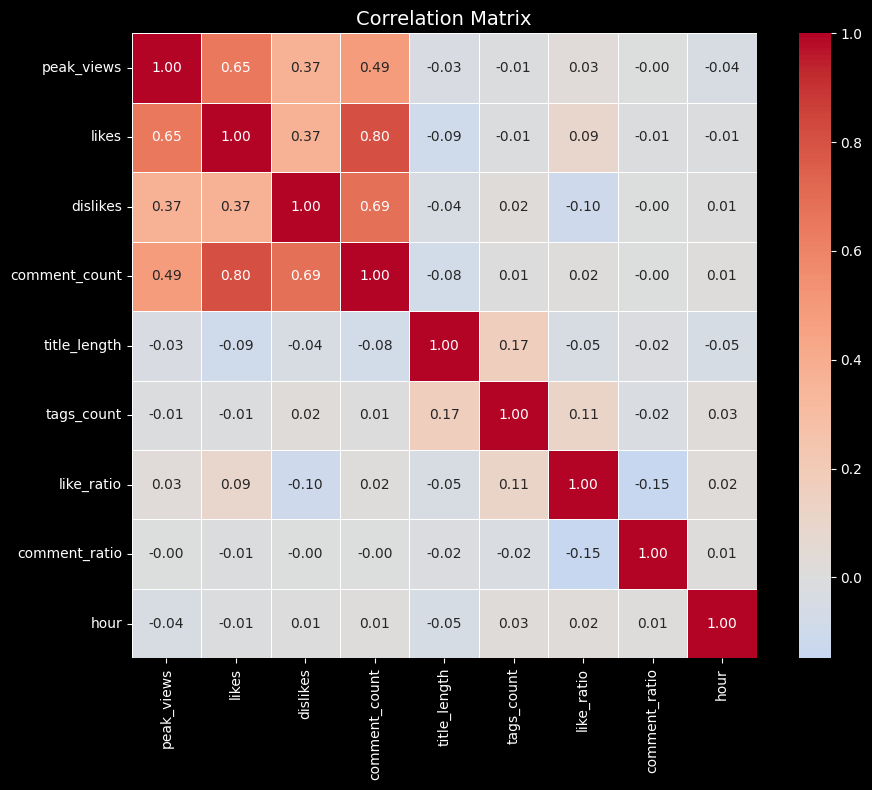

In [14]:
corr_cols = ['peak_views','likes','dislikes','comment_count',
             'title_length','tags_count','like_ratio','comment_ratio','hour']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

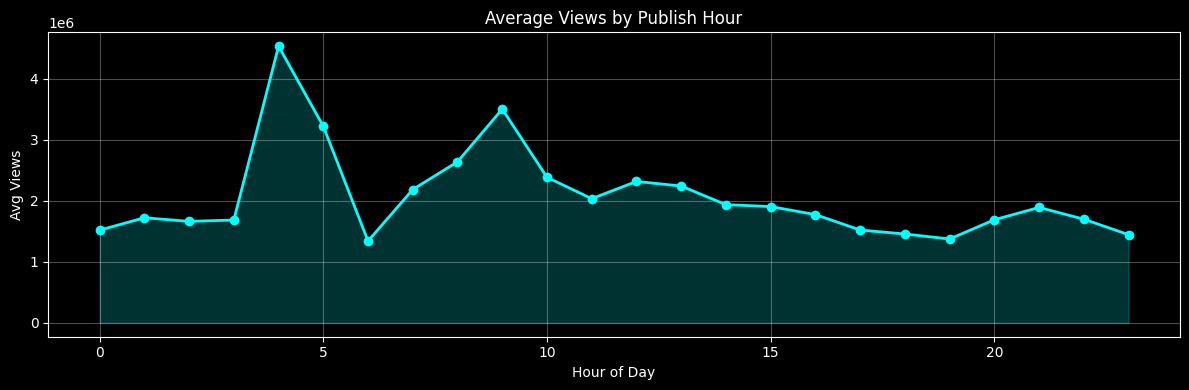

In [15]:
hourly_views = df.groupby('hour')['peak_views'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly_views.index, hourly_views.values, marker='o', color='cyan', linewidth=2)
plt.fill_between(hourly_views.index, hourly_views.values, alpha=0.2, color='cyan')
plt.title('Average Views by Publish Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Views')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

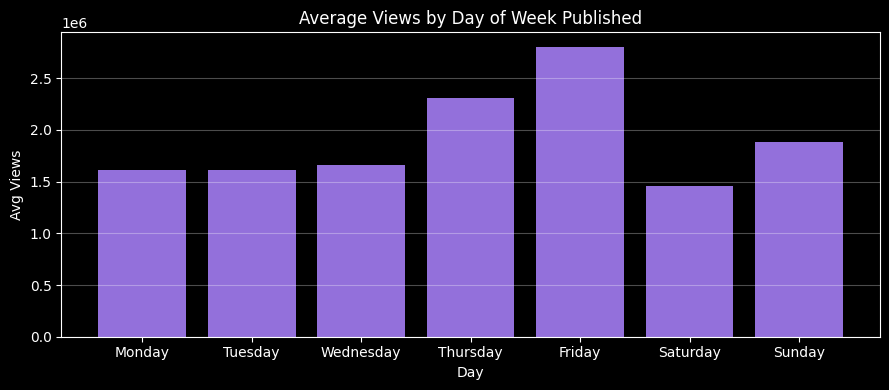

In [16]:
day_views = df.groupby('published_day_of_week')['peak_views'].mean().reindex(day_order)

plt.figure(figsize=(9, 4))
bars = plt.bar(day_views.index, day_views.values, color='mediumpurple', edgecolor='none')
plt.title('Average Views by Day of Week Published')
plt.xlabel('Day')
plt.ylabel('Avg Views')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

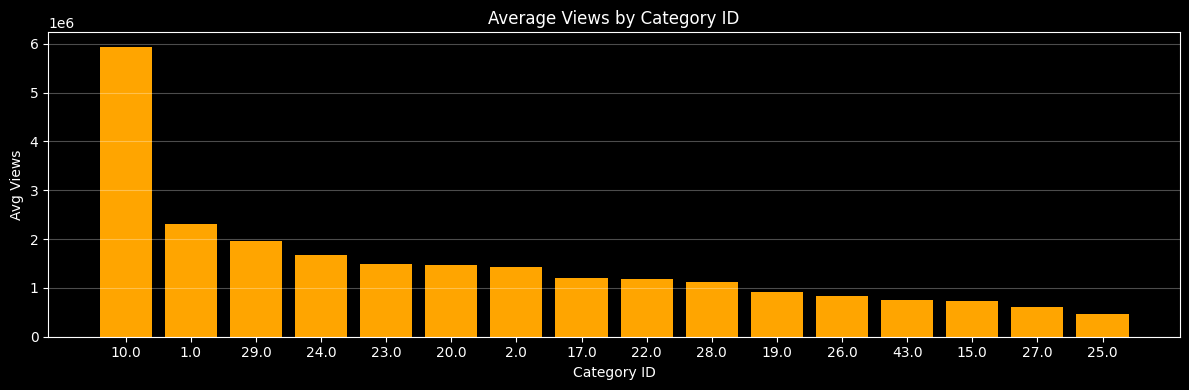

In [17]:
category_views = df.groupby('category_id')['peak_views'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(category_views.index.astype(str), category_views.values, color='orange', edgecolor='none')
plt.title('Average Views by Category ID')
plt.xlabel('Category ID')
plt.ylabel('Avg Views')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

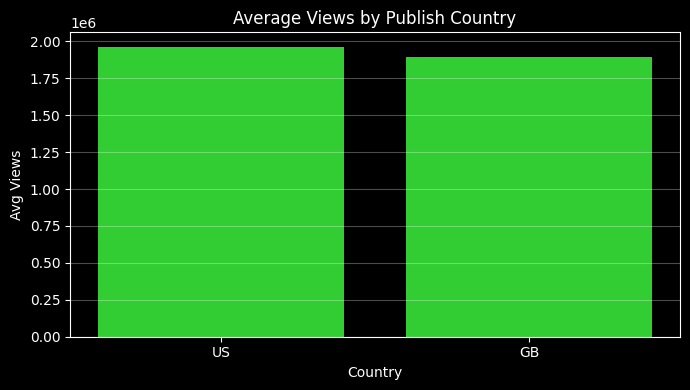

In [18]:
country_views = df.groupby('publish_country')['peak_views'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(country_views.index, country_views.values, color='limegreen', edgecolor='none')
plt.title('Average Views by Publish Country')
plt.xlabel('Country')
plt.ylabel('Avg Views')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

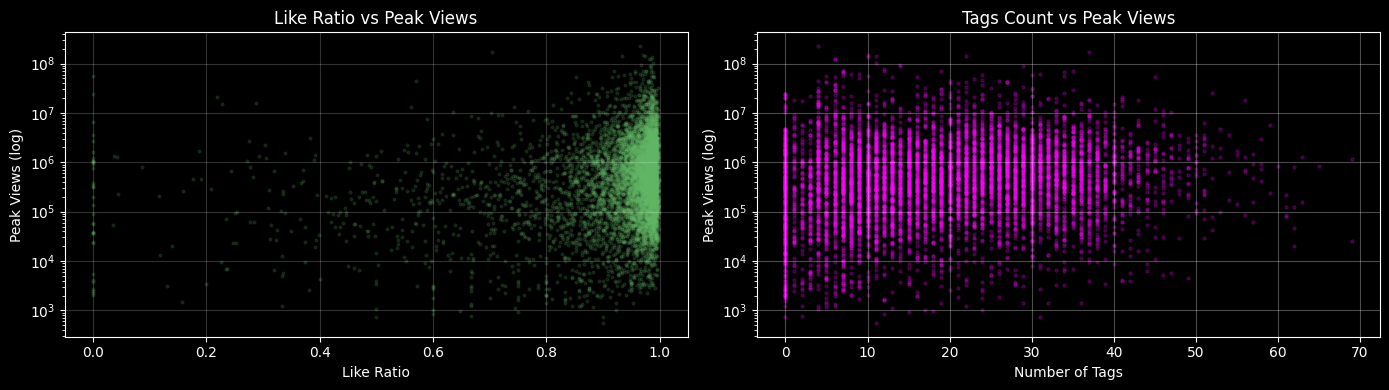

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['like_ratio'], df['peak_views'], alpha=0.15, color='#66bb6a', s=4)
axes[0].set_yscale('log')
axes[0].set_title('Like Ratio vs Peak Views')
axes[0].set_xlabel('Like Ratio')
axes[0].set_ylabel('Peak Views (log)')
axes[0].grid(alpha=0.2)
axes[1].scatter(df['tags_count'], df['peak_views'], alpha=0.2, color='magenta', s=5)
axes[1].set_yscale('log')
axes[1].set_title('Tags Count vs Peak Views')
axes[1].set_xlabel('Number of Tags')
axes[1].set_ylabel('Peak Views (log)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
top_videos = df.sort_values('peak_views', ascending=False).head(10)
print('Top 10 Videos by Views:')
print(top_videos[['title','channel_title','publish_country','peak_views']].to_string(index=False))

Top 10 Videos by Views:
                                                           title        channel_title publish_country  peak_views
             Childish Gambino - This Is America (Official Video)  ChildishGambinoVEVO              US 225211923.0
              YouTube Rewind: The Shape of 2017 | #YouTubeRewind    YouTube Spotlight              US 169884583.0
                            Ariana Grande - No Tears Left To Cry     ArianaGrandeVevo              US 148689896.0
                      Luis Fonsi, Demi Lovato - Ã‰chame La Culpa        LuisFonsiVEVO              US 143408235.0
            Becky G, Natti Natasha - Sin Pijama (Official Video)           BeckyGVEVO              US 139334502.0
                     Ed Sheeran - Perfect (Official Music Video)           Ed Sheeran              GB 138578860.0
                   BTS (ë°©íƒ„ì†Œë…„ë‹¨) 'FAKE LOVE' Official MV              ibighit              US 123010920.0
                  The Weeknd - Call Out My Name (Official Video)

In [21]:
FEATURES = [
    'likes', 'dislikes', 'comment_count',
    'title_length', 'title_char_length', 'tags_count',
    'like_ratio', 'comment_ratio', 'dislike_ratio',
    'hour', 'day_num', 'category_id', 'country_enc',
    'comments_disabled_int', 'ratings_disabled_int'
]

X = df[FEATURES].copy()
views = df['views'].copy()

In [22]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, views_train, views_test = train_test_split(
   X, df['peak_views'], test_size=0.2, random_state=42


)



In [23]:
VIRAL_THRESHOLD = df.loc[X_train_raw.index, 'peak_views'].median()
y_train = (df.loc[X_train_raw.index, 'peak_views'] > VIRAL_THRESHOLD).astype(int)
y_test  = (df.loc[X_test_raw.index,  'peak_views'] > VIRAL_THRESHOLD).astype(int)

In [24]:
X_train = X_train_raw.values
X_test  = X_test_raw.values

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 0.8376753507014028


In [26]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.8229792919171677


In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.8423513694054776


In [28]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 0.8610554442217769


In [29]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),

}

print("\nModel Comparison:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

print("\nBest Model:", max(results, key=results.get))


Model Comparison:
Logistic Regression: 0.8377
Decision Tree: 0.8230
KNN: 0.8424
Random Forest: 0.8611

Best Model: Random Forest


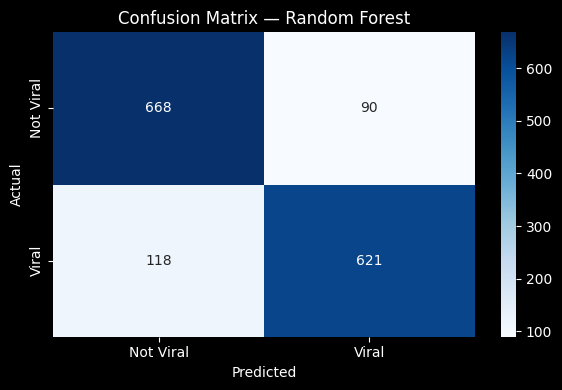


Classification Report — Random Forest:
              precision    recall  f1-score   support

   Not Viral       0.85      0.88      0.87       758
       Viral       0.87      0.84      0.86       739

    accuracy                           0.86      1497
   macro avg       0.86      0.86      0.86      1497
weighted avg       0.86      0.86      0.86      1497



In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Viral','Viral'],
            yticklabels=['Not Viral','Viral'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\nClassification Report — Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['Not Viral','Viral']))

In [32]:
y_proba_lr  = lr.predict_proba(X_test)[:, 1]
y_proba_dt  = dt.predict_proba(X_test)[:, 1]
y_proba_knn = knn.predict_proba(X_test)[:, 1]
y_proba_rf  = rf.predict_proba(X_test)[:, 1]


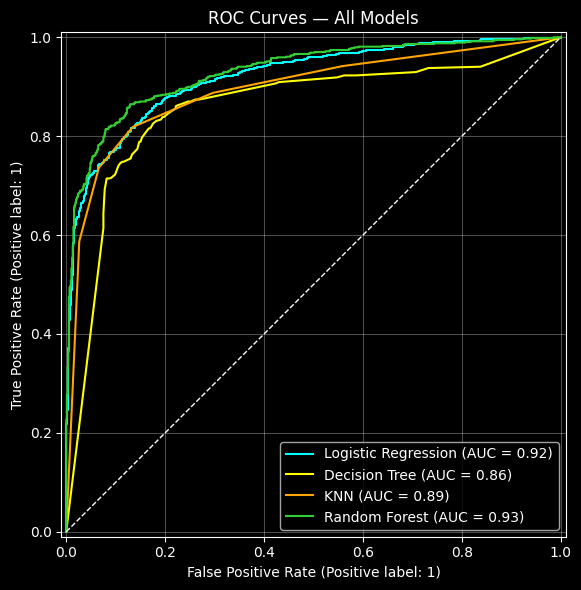

In [34]:
from sklearn.metrics import roc_auc_score , RocCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))

plot_models = {
    'Logistic Regression': (y_proba_lr,  'cyan'),
    'Decision Tree':       (y_proba_dt,  'yellow'),
    'KNN':                 (y_proba_knn, 'orange'),
    'Random Forest':       (y_proba_rf,  'limegreen'),

}

for name, (proba, color) in plot_models.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax, color=color)

ax.plot([0,1],[0,1],'w--', linewidth=1, label='Random')
ax.set_title('ROC Curves — All Models')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

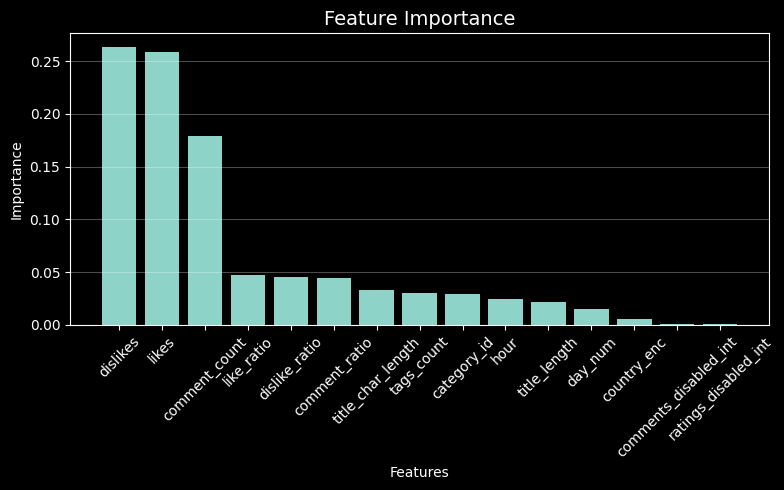

In [35]:
# Sort importance (descending)
importance = pd.Series(rf.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

# Bar plot (straight, top = most important)
plt.bar(importance.index, importance.values)

plt.title("Feature Importance", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()